In [1]:
# =============================================================================
# CELL 1: Import Libraries
# =============================================================================

import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Running on CPU (as per project requirements)")
print("✓ Libraries imported successfully")

c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0
Running on CPU (as per project requirements)
✓ Libraries imported successfully


In [2]:
# =============================================================================
# CELL 2: Setup Paths & Load Configuration
# =============================================================================

# Get the base directory (parent of 'notebooks' folder)
BASE_DIR = os.path.dirname(os.getcwd())

# Define paths
PREPROCESSED_DIR = os.path.join(BASE_DIR, 'preprocessed')
MODEL_PATH = os.path.join(BASE_DIR, 'model.keras')
RESULT_CSV_PATH = os.path.join(BASE_DIR, 'result.csv')

# Load configuration
with open(os.path.join(PREPROCESSED_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

CHAR_H = config['CHAR_H']
CHAR_W = config['CHAR_W']
NUM_CHANNELS = config['NUM_CHANNELS']
NUM_CLASSES = config['NUM_CLASSES']

print("CONFIGURATION LOADED")
print("=" * 60)
print(f"Character size: {CHAR_W}×{CHAR_H}×{NUM_CHANNELS}")
print(f"Number of classes (writers): {NUM_CLASSES}")
print(f"Training samples: {config['train_samples']}")
print(f"Test samples: {config['test_samples']}")
print(f"Test images: {config['test_images']}")
print(f"\nModel will be saved to: {MODEL_PATH}")

CONFIGURATION LOADED
Character size: 64×64×3
Number of classes (writers): 70
Training samples: 37885
Test samples: 14615
Test images: 140

Model will be saved to: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras


In [3]:
# =============================================================================
# CELL 3: Load Preprocessed Data
# =============================================================================

print("LOADING PREPROCESSED DATA")
print("=" * 60)

# Load character numpy arrays
X_train = np.load(os.path.join(PREPROCESSED_DIR, 'X_train_chars.npy'))
y_train = np.load(os.path.join(PREPROCESSED_DIR, 'y_train.npy'))
X_test = np.load(os.path.join(PREPROCESSED_DIR, 'X_test_chars.npy'))
y_test = np.load(os.path.join(PREPROCESSED_DIR, 'y_test.npy'))

# Load label encoder
with open(os.path.join(PREPROCESSED_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

# Load test character map (for aggregation)
with open(os.path.join(PREPROCESSED_DIR, 'test_char_map.pkl'), 'rb') as f:
    test_char_map = pickle.load(f)

# Load test filenames
with open(os.path.join(PREPROCESSED_DIR, 'test_filenames.pkl'), 'rb') as f:
    test_filenames = pickle.load(f)

# Load class weights
with open(os.path.join(PREPROCESSED_DIR, 'class_weights.pkl'), 'rb') as f:
    class_weights = pickle.load(f)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nLabel encoder classes: {len(label_encoder.classes_)}")
print(f"Test images (for aggregation): {len(test_filenames)}")
print(f"Class weights computed: {len(class_weights)}")
print("\n✓ Data loaded successfully")

LOADING PREPROCESSED DATA
X_train shape: (37885, 64, 64, 3)
y_train shape: (37885,)
X_test shape: (14615, 64, 64, 3)
y_test shape: (14615,)

Label encoder classes: 70
Test images (for aggregation): 140
Class weights computed: 70

✓ Data loaded successfully


In [4]:
# =============================================================================
# CELL 4: Prepare Data for Training
# =============================================================================

print("PREPARING DATA FOR TRAINING")
print("=" * 60)

# Data is already normalized to [0, 1] during preprocessing
print(f"X_train - dtype: {X_train.dtype}, range: [{X_train.min():.3f}, {X_train.max():.3f}]")

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"\ny_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

# Split a portion for validation
VAL_FRACTION = 0.10
val_count = max(1, int(VAL_FRACTION * len(X_train)))

X_val = X_train[:val_count]
y_val = y_train_cat[:val_count]
X_train_final = X_train[val_count:]
y_train_final = y_train_cat[val_count:]

print(f"\nTraining set: {X_train_final.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

PREPARING DATA FOR TRAINING
X_train - dtype: float32, range: [0.000, 1.000]

y_train_cat shape: (37885, 70)
y_test_cat shape: (14615, 70)

Training set: 34097 samples
Validation set: 3788 samples
Test set: 14615 samples


CLASS DISTRIBUTION


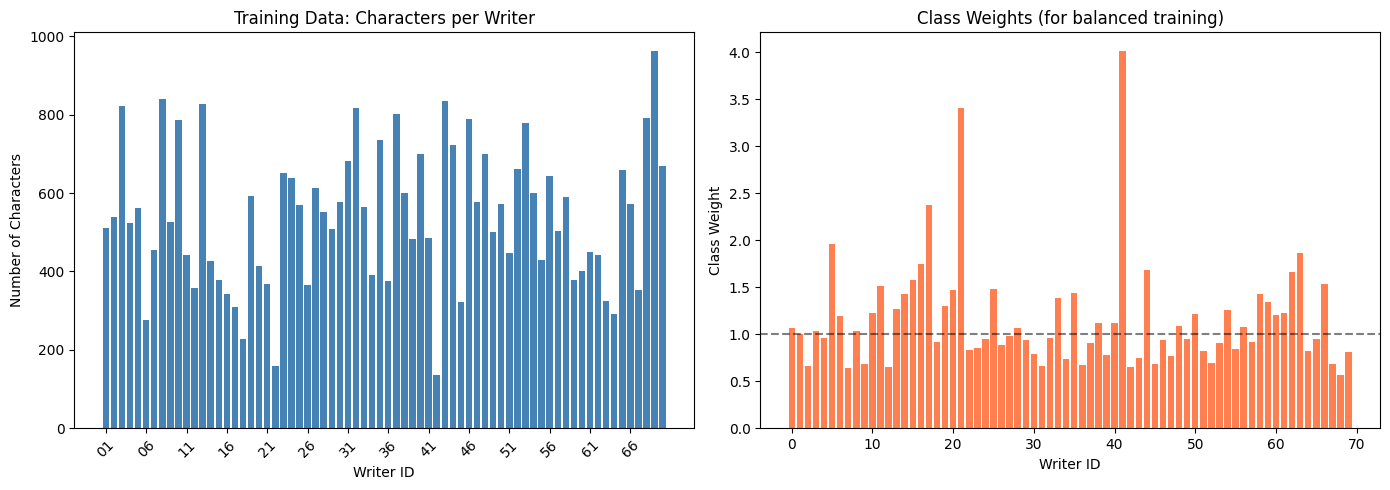

Character counts - Min: 135, Max: 962, Median: 544


In [5]:
# =============================================================================
# CELL 5: Visualize Class Distribution
# =============================================================================

print("CLASS DISTRIBUTION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training distribution
train_counts = Counter(y_train.tolist())
train_sorted = sorted(train_counts.items())
x_labels = [label_encoder.inverse_transform([k])[0] for k, v in train_sorted]
y_counts = [v for k, v in train_sorted]

axes[0].bar(range(len(y_counts)), y_counts, color='steelblue')
axes[0].set_xlabel('Writer ID')
axes[0].set_ylabel('Number of Characters')
axes[0].set_title('Training Data: Characters per Writer')
axes[0].set_xticks(range(0, len(y_counts), 5))
axes[0].set_xticklabels([x_labels[i] for i in range(0, len(x_labels), 5)], rotation=45)

# Class weights
weights_sorted = [class_weights[k] for k, v in train_sorted]
axes[1].bar(range(len(weights_sorted)), weights_sorted, color='coral')
axes[1].set_xlabel('Writer ID')
axes[1].set_ylabel('Class Weight')
axes[1].set_title('Class Weights (for balanced training)')
axes[1].axhline(y=1.0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Character counts - Min: {min(y_counts)}, Max: {max(y_counts)}, Median: {np.median(y_counts):.0f}")

In [6]:
# =============================================================================
# CELL 6: Define CNN Model Architecture
# =============================================================================

def build_character_cnn(input_shape=(CHAR_H, CHAR_W, NUM_CHANNELS), num_classes=NUM_CLASSES):
    """
    CNN Model for Writer Identification from Character Images.
    
    Architecture:
    - 5 convolutional blocks with increasing filters
    - In-model augmentation (character-level)
    - Global average pooling
    - Large dense layer for 70-class discrimination
    
    Input: (64, 64, 3) RGB character images
    Output: (70,) softmax probabilities
    """
    
    inp = layers.Input(shape=input_shape)
    
    # In-model augmentation (only during training)
    # Light augmentation since characters are already variable
    x = layers.RandomRotation(0.05)(inp)  # ±5% rotation
    x = layers.RandomTranslation(0.03, 0.03)(x)  # ±3% translation
    
    # Convolutional blocks: progressively extract features
    filter_sizes = [32, 64, 128, 256, 256]
    
    for filters in filter_sizes:
        x = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.25)(x)
    
    # After 5 pooling layers: 64 → 32 → 16 → 8 → 4 → 2
    # Output: (2, 2, 256)
    
    # Global average pooling
    x = layers.GlobalAveragePooling2D()(x)
    
    # Dense layers for classification
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    # Output layer
    out = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inp, out)

# Create the model
print("MODEL ARCHITECTURE")
print("=" * 60)
print(f"Input shape: ({CHAR_H}, {CHAR_W}, {NUM_CHANNELS})")
print(f"Output classes: {NUM_CLASSES}")
print("\nBuilding character-based CNN model...\n")

model = build_character_cnn()
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Estimated model size: {total_params * 4 / (1024**2):.2f} MB (float32)")

MODEL ARCHITECTURE
Input shape: (64, 64, 3)
Output classes: 70

Building character-based CNN model...



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 64, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,320,454 (5.04 MB)

 Trainable params: 1,316,934 (5.02 MB)

 Non-trainable params: 3,520 (13.75 KB)


Total parameters: 1,320,454
Estimated model size: 5.04 MB (float32)


In [7]:
# =============================================================================
# CELL 7: Compile Model
# =============================================================================

print("MODEL COMPILATION")
print("=" * 60)

LEARNING_RATE = 0.001

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss: Categorical Crossentropy")
print(f"Metrics: Accuracy")
print(f"\n✓ Model compiled and ready for training")

MODEL COMPILATION
Optimizer: Adam (lr=0.001)
Loss: Categorical Crossentropy
Metrics: Accuracy

✓ Model compiled and ready for training


In [8]:
# =============================================================================
# CELL 8: Configure Training
# =============================================================================

print("TRAINING CONFIGURATION")
print("=" * 60)

BATCH_SIZE = 64
EPOCHS = 80

# Define callbacks
training_callbacks = [
    # Save best model
    callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),
    
    # Early stopping
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    
    # Learning rate reduction
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        verbose=1,
        min_lr=1e-6
    )
]

print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print(f"Training samples: {len(X_train_final)}")
print(f"Steps per epoch: ~{len(X_train_final) // BATCH_SIZE}")
print(f"\nCallbacks:")
print(f"  1. ModelCheckpoint: Save best model (by val_accuracy)")
print(f"  2. EarlyStopping: Stop if no improvement for 12 epochs")
print(f"  3. ReduceLROnPlateau: Halve LR if val_loss plateaus")
print(f"\nClass weights: Enabled (balancing {NUM_CLASSES} classes)")

TRAINING CONFIGURATION
Batch size: 64
Max epochs: 80
Training samples: 34097
Steps per epoch: ~532

Callbacks:
  1. ModelCheckpoint: Save best model (by val_accuracy)
  2. EarlyStopping: Stop if no improvement for 12 epochs
  3. ReduceLROnPlateau: Halve LR if val_loss plateaus

Class weights: Enabled (balancing 70 classes)


In [9]:
# =============================================================================
# CELL 9: Train Model
# =============================================================================

print("TRAINING MODEL")
print("=" * 60)
print("This may take 30-60 minutes on CPU...\n")

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    class_weight=class_weights,
    callbacks=training_callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Model saved to: {MODEL_PATH}")

TRAINING MODEL
This may take 30-60 minutes on CPU...

Epoch 1/80
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0250 - loss: 5.0725
Epoch 1: val_accuracy improved from None to 0.03405, saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras

Epoch 1: finished saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras
533/533 ━━━━━━━━━━━━━━━━━━━━ 47s 84ms/step - accuracy: 0.0321 - loss: 4.7954 - val_accuracy: 0.0341 - val_loss: 5.0093 - learning_rate: 0.0010
Epoch 2/80
533/533 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.0554 - loss: 4.3253
Epoch 2: val_accuracy improved from 0.03405 to 0.04435, saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras

Epoch 2: finished saving model to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras
533/533 ━━━━━━━━━━━━━━━━━━━━ 47s 88ms/step - accuracy: 0.0643 - loss: 4.1974 - val_accuracy: 0.044

TRAINING HISTORY


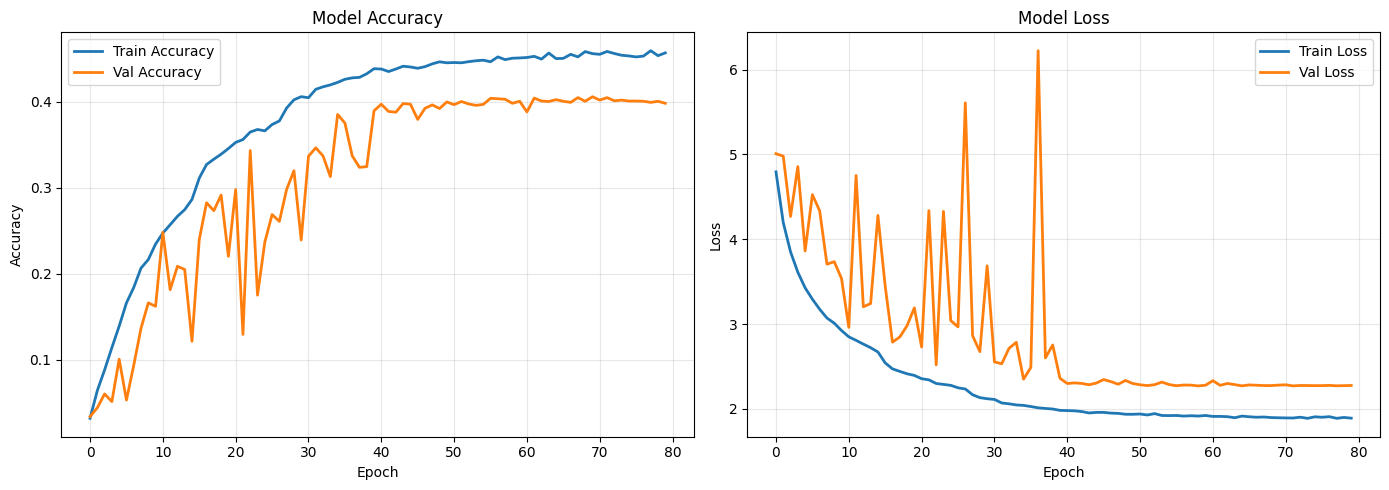


✓ Training history saved to training_history.png


In [19]:
# =============================================================================
# CELL 10: Plot Training History
# =============================================================================

print("TRAINING HISTORY")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_history.png'), dpi=150)
plt.show()

print(f"\n✓ Training history saved to training_history.png")

In [20]:
# =============================================================================
# CELL 11: Load Best Model
# =============================================================================

print("LOADING BEST MODEL")
print("=" * 60)

# Load the best model saved during training
model = keras.models.load_model(MODEL_PATH)

print(f"✓ Loaded model from {MODEL_PATH}")
print(f"  Input shape: {model.input_shape}")
print(f"  Output shape: {model.output_shape}")

LOADING BEST MODEL
✓ Loaded model from c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras
  Input shape: (None, 64, 64, 3)
  Output shape: (None, 70)


In [12]:
# =============================================================================
# CELL 12: Character-Level Evaluation
# =============================================================================

print("CHARACTER-LEVEL EVALUATION (Test Set)")
print("=" * 60)

# Evaluate on all test characters
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)

print(f"\nCharacter-level test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Character-level test loss: {test_loss:.4f}")

# Get predictions
print("\nGenerating predictions for all test characters...")
all_test_probs = model.predict(X_test, verbose=1)
char_predictions = np.argmax(all_test_probs, axis=1)

char_correct = np.sum(char_predictions == y_test)
print(f"\nCorrect character predictions: {char_correct}/{len(y_test)}")

CHARACTER-LEVEL EVALUATION (Test Set)
457/457 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3415 - loss: 2.8099

Character-level test accuracy: 0.3415 (34.15%)
Character-level test loss: 2.8099

Generating predictions for all test characters...
457/457 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step

Correct character predictions: 4991/14615


In [13]:
# =============================================================================
# CELL 13: Image-Level Aggregation
# =============================================================================

def aggregate_char_predictions(char_probs, method='weighted_mean'):
    """
    Aggregate character-level predictions to image-level prediction.
    
    Args:
        char_probs: (N, num_classes) array of softmax probabilities
        method: 'mean', 'vote', or 'weighted_mean'
    
    Returns:
        predicted_class: int
        confidence: float
        aggregated_probs: (num_classes,) array
    """
    if len(char_probs) == 0:
        return -1, 0.0, np.zeros(NUM_CLASSES)
    
    if method == 'mean':
        # Simple average
        aggregated_probs = np.mean(char_probs, axis=0)
        
    elif method == 'vote':
        # Majority voting
        votes = np.argmax(char_probs, axis=1)
        vote_counts = np.bincount(votes, minlength=NUM_CLASSES)
        aggregated_probs = vote_counts / len(votes)
        
    elif method == 'weighted_mean':
        # Weight by confidence (max probability)
        confidences = np.max(char_probs, axis=1)
        weights = confidences ** 2  # Square for emphasis
        weights = weights / np.sum(weights)
        aggregated_probs = np.sum(char_probs * weights[:, np.newaxis], axis=0)
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    predicted_class = np.argmax(aggregated_probs)
    confidence = aggregated_probs[predicted_class]
    
    return predicted_class, confidence, aggregated_probs

print("✓ Aggregation function defined")
print("\nMethods: 'mean', 'vote', 'weighted_mean'")

✓ Aggregation function defined

Methods: 'mean', 'vote', 'weighted_mean'


In [14]:
# =============================================================================
# CELL 14: Image-Level Evaluation
# =============================================================================

print("IMAGE-LEVEL EVALUATION (Test Set)")
print("=" * 60)

# Compare different aggregation methods
methods = ['mean', 'weighted_mean', 'vote']
method_results = {}

for method in methods:
    image_predictions = []
    image_true_labels = []
    image_confidences = []
    
    for filename in test_filenames:
        start_idx, end_idx = test_char_map[filename]
        
        # Get true label from filename
        true_writer = filename[:2]
        true_class = label_encoder.transform([true_writer])[0]
        
        if end_idx > start_idx:
            char_probs = all_test_probs[start_idx:end_idx]
            pred_class, confidence, _ = aggregate_char_predictions(char_probs, method=method)
        else:
            pred_class, confidence = 0, 0.0
        
        image_predictions.append(pred_class)
        image_true_labels.append(true_class)
        image_confidences.append(confidence)
    
    # Calculate accuracy
    correct = np.sum(np.array(image_predictions) == np.array(image_true_labels))
    accuracy = correct / len(image_true_labels)
    
    method_results[method] = {
        'accuracy': accuracy,
        'predictions': image_predictions,
        'true_labels': image_true_labels,
        'confidences': image_confidences
    }

# Print comparison
print("\nAggregation Method Comparison:")
print("-" * 40)
for method, results in method_results.items():
    acc = results['accuracy']
    print(f"  {method:15s}: {acc:.4f} ({acc*100:.2f}%)")

# Use best method
best_method = max(method_results, key=lambda x: method_results[x]['accuracy'])
print(f"\n→ Best method: {best_method}")

# Final results
final_results = method_results[best_method]
image_accuracy = final_results['accuracy']
image_predictions = np.array(final_results['predictions'])
image_true_labels = np.array(final_results['true_labels'])

print(f"\n" + "=" * 60)
print("FINAL IMAGE-LEVEL RESULTS")
print("=" * 60)
print(f"Test images: {len(image_true_labels)}")
print(f"Correct predictions: {np.sum(image_predictions == image_true_labels)}")
print(f"Image-level accuracy: {image_accuracy:.4f} ({image_accuracy*100:.2f}%)")

IMAGE-LEVEL EVALUATION (Test Set)

Aggregation Method Comparison:
----------------------------------------
  mean           : 0.9071 (90.71%)
  weighted_mean  : 0.8429 (84.29%)
  vote           : 0.8786 (87.86%)

→ Best method: mean

FINAL IMAGE-LEVEL RESULTS
Test images: 140
Correct predictions: 127
Image-level accuracy: 0.9071 (90.71%)


In [15]:
# =============================================================================
# CELL 15: Generate result.csv
# =============================================================================

print("GENERATING result.csv")
print("=" * 60)

# Create results DataFrame
results_data = []

for i, filename in enumerate(test_filenames):
    actual_label = filename[:2]
    predicted_idx = image_predictions[i]
    predicted_label = label_encoder.inverse_transform([predicted_idx])[0]
    
    results_data.append({
        'filename': filename,
        'actual_label': actual_label,
        'predicted_label': predicted_label
    })

results_df = pd.DataFrame(results_data)

# Add correctness column
results_df['correct'] = results_df['actual_label'] == results_df['predicted_label']

# Save to CSV
results_df.to_csv(RESULT_CSV_PATH, index=False)

print(f"✓ Saved to {RESULT_CSV_PATH}")
print(f"\nSample predictions:")
print(results_df.head(10).to_string(index=False))

# Summary
correct_count = results_df['correct'].sum()
total_count = len(results_df)
print(f"\nSummary: {correct_count}/{total_count} correct ({correct_count/total_count*100:.2f}%)")

GENERATING result.csv
✓ Saved to c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\result.csv

Sample predictions:
    filename actual_label predicted_label  correct
01_2_281.png           01              01     True
01_2_491.png           01              01     True
02_2_352.png           02              65    False
02_2_492.png           02              02     True
03_2_353.png           03              03     True
03_2_493.png           03              03     True
04_2_424.png           04              04     True
04_2_494.png           04              04     True
05_2_355.png           05              05     True
05_2_495.png           05              05     True

Summary: 127/140 correct (90.71%)


CONFUSION MATRIX


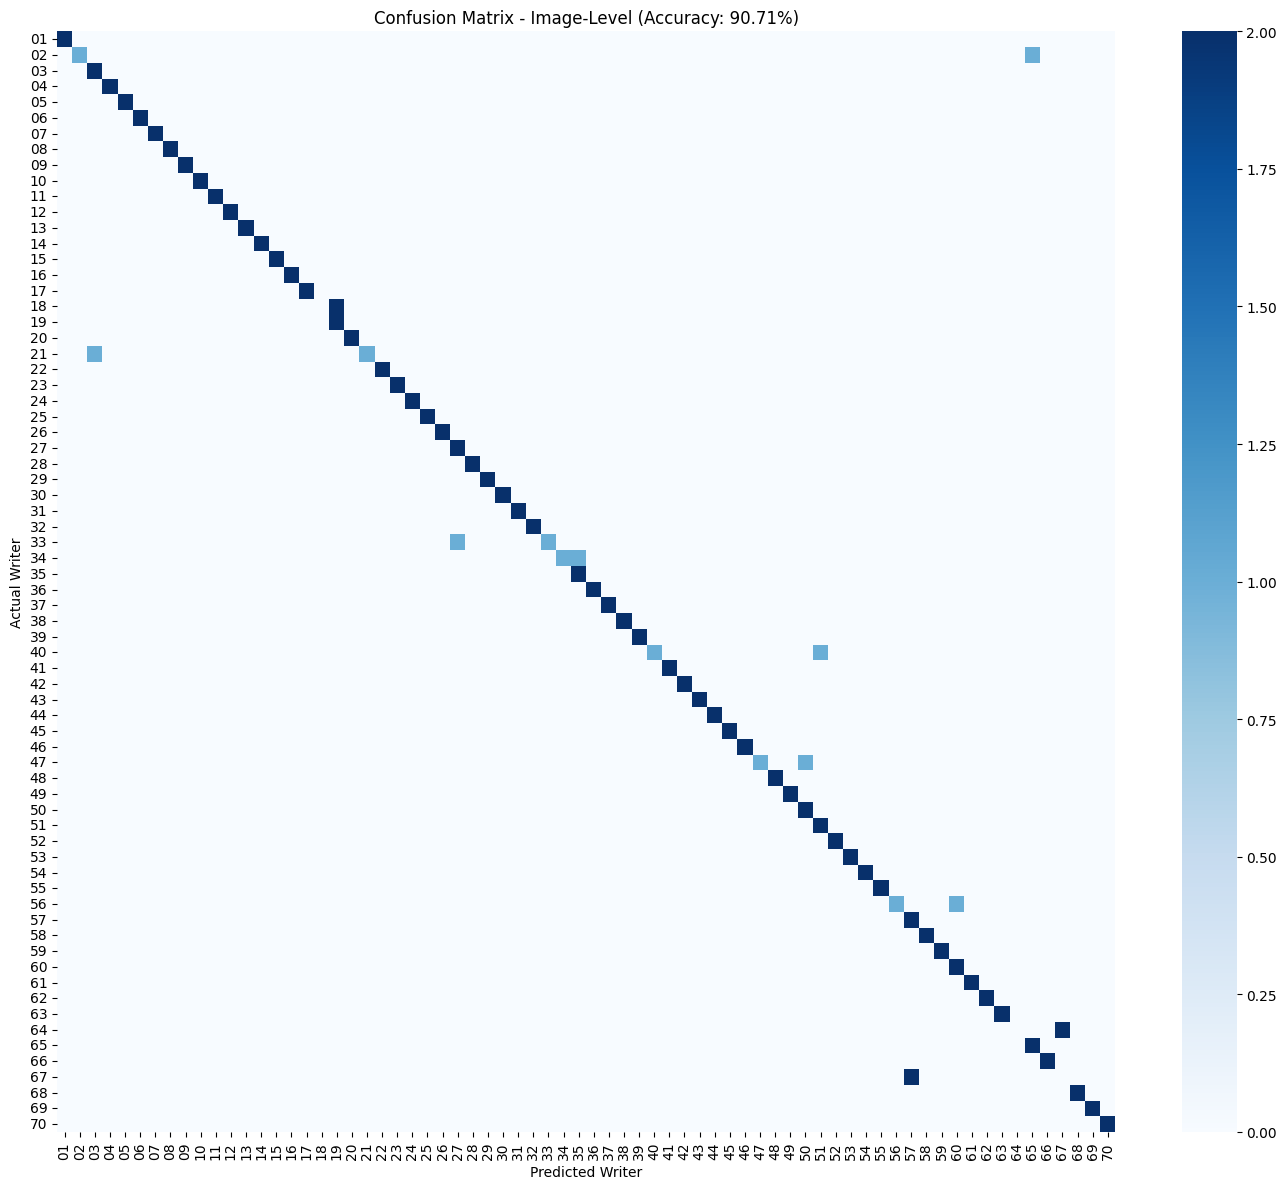


✓ Confusion matrix saved to confusion_matrix.png


In [16]:
# =============================================================================
# CELL 16: Confusion Matrix
# =============================================================================

print("CONFUSION MATRIX")
print("=" * 60)

# Compute confusion matrix
cm = confusion_matrix(image_true_labels, image_predictions)

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Writer')
plt.ylabel('Actual Writer')
plt.title(f'Confusion Matrix - Image-Level (Accuracy: {image_accuracy:.2%})')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print(f"\n✓ Confusion matrix saved to confusion_matrix.png")

In [17]:
# =============================================================================
# CELL 17: Error Analysis
# =============================================================================

print("ERROR ANALYSIS")
print("=" * 60)

# Find misclassified images
errors = results_df[~results_df['correct']]

print(f"Total errors: {len(errors)} / {len(results_df)}")
print(f"\nMisclassified images:")
print(errors[['filename', 'actual_label', 'predicted_label']].to_string(index=False))

# Most confused pairs
if len(errors) > 0:
    print(f"\nMost common confusion pairs:")
    confusion_pairs = errors.groupby(['actual_label', 'predicted_label']).size().sort_values(ascending=False)
    print(confusion_pairs.head(10))

ERROR ANALYSIS
Total errors: 13 / 140

Misclassified images:
    filename actual_label predicted_label
02_2_352.png           02              65
18_2_368.png           18              19
18_2_508.png           18              19
21_2_301.png           21              03
33_2_383.png           33              27
34_2_524.png           34              35
40_2_460.png           40              51
47_2_397.png           47              50
56_2_546.png           56              60
64_2_414.png           64              67
64_2_554.png           64              67
67_2_487.png           67              57
67_2_557.png           67              57

Most common confusion pairs:
actual_label  predicted_label
18            19                 2
64            67                 2
67            57                 2
02            65                 1
21            03                 1
33            27                 1
40            51                 1
34            35                 1
56         

In [18]:
# =============================================================================
# CELL 18: Final Summary
# =============================================================================

print("=" * 60)
print("TRAINING COMPLETE - FINAL SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset:")
print(f"   Training characters: {config['train_samples']}")
print(f"   Test characters: {config['test_samples']}")
print(f"   Test images: {config['test_images']}")

print(f"\n🧠 Model:")
print(f"   Architecture: Character-based CNN ({CHAR_H}×{CHAR_W} input)")
print(f"   Parameters: {model.count_params():,}")
print(f"   Saved to: {MODEL_PATH}")

print(f"\n📈 Performance:")
print(f"   Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"   Character-level test accuracy: {test_acc:.4f}")
print(f"   Image-level test accuracy: {image_accuracy:.4f}")

print(f"\n📁 Output files:")
print(f"   - model.keras (trained model)")
print(f"   - result.csv (predictions)")
print(f"   - training_history.png")
print(f"   - confusion_matrix.png")

print(f"\n✅ Ready for deployment with run.py!")

TRAINING COMPLETE - FINAL SUMMARY

📊 Dataset:
   Training characters: 37885
   Test characters: 14615
   Test images: 140

🧠 Model:
   Architecture: Character-based CNN (64×64 input)
   Parameters: 1,320,454
   Saved to: c:\Users\Putrajaya-PC12\RMK_CONFIDENTIAL\dl-handwriting-recognition\model.keras

📈 Performance:
   Best validation accuracy: 0.4060
   Character-level test accuracy: 0.3415
   Image-level test accuracy: 0.9071

📁 Output files:
   - model.keras (trained model)
   - result.csv (predictions)
   - training_history.png
   - confusion_matrix.png

✅ Ready for deployment with run.py!
